In [1]:
# ! pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu122

In [2]:
# ! pip install transformers datasets torch

In [3]:
# ! pip install scikit-learn
# ! pip install scikit-learn numpy pandas matplotlib

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

/home/ebratul/Documents/code/mubarak/torch_gpu_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
emotions = load_dataset("emotion")
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
emotions["train"][:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [7]:
import pandas as pd

df_train = pd.DataFrame(emotions["train"])

df_train.head(5)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
df_train['label'].unique()


array([0, 3, 2, 5, 4, 1])

In [9]:
import pandas as pd

df_test = pd.DataFrame(emotions["test"])

df_test.head(3)

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0


In [10]:
for emotion in df_train["label"].unique():
    example = df_train[df_train["label"] == emotion]["text"].iloc[0]
    print(f"Class: {emotion} → Example: {example}")

Class: 0 → Example: i didnt feel humiliated
Class: 3 → Example: im grabbing a minute to post i feel greedy wrong
Class: 2 → Example: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Class: 5 → Example: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Class: 4 → Example: i feel as confused about life as a teenager or as jaded as a year old man
Class: 1 → Example: i have been with petronas for years i feel that petronas has performed well and made a huge profit


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
# 1. Load dataset
dataset = load_dataset("emotion")
train_data = dataset["train"]
test_data = dataset["test"]

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [14]:
# 2. Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()   # ✅ inference mode

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2271.08it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [15]:
# 3. Custom Dataset
class EmotionDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=128):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]["text"]
        label = self.dataset[idx]["label"]

        # Tokenize
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=self.max_length
        ).to(device)

        # Extract CLS embedding
        with torch.no_grad():
            outputs = bert_model(**inputs)
            cls_hidden_state = outputs.last_hidden_state[:, 0, :]  # [1, hidden_dim]

        return cls_hidden_state.squeeze(0), torch.tensor(label, dtype=torch.long)

In [16]:
# 4. Wrap datasets
train_dataset = EmotionDataset(train_data, tokenizer)
test_dataset = EmotionDataset(test_data, tokenizer)

# 5. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# 6. Classifier on top of BERT embeddings
num_classes = dataset["train"].features["label"].num_classes
hidden_dim = bert_model.config.hidden_size

classifier = nn.Linear(hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=1e-3)

In [17]:
# 7. Training loop
epochs = 1
for epoch in range(epochs):
    classifier.train()
    total_loss, correct, total = 0, 0, 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {correct/total:.4f}")

Epoch 1/1, Loss: 1.3714, Accuracy: 0.4884


In [18]:
# 8. Evaluation
classifier.eval()
correct, total = 0, 0
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = classifier(features)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {correct/total:.4f}")

Test Accuracy: 0.5360


In [19]:
# 9. Prediction function
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)
        cls_hidden_state = outputs.last_hidden_state[:, 0, :]
        logits = classifier(cls_hidden_state)
        probs = torch.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()

    label_names = dataset["train"].features["label"].names
    return label_names[pred_class], probs[0][pred_class].item()

In [20]:
#10. Example prediction
print(predict("I feel so happy today!"))
print(predict("This is frustrating and makes me angry."))

('joy', 0.8150637149810791)
('anger', 0.421755313873291)


In [21]:
! pip install datasets transformers accelerate accelerate -U


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import load_dataset
import torch
import pandas as pd

In [23]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding = "max_length",
        truncation = True,
        max_length = 128
    )

In [24]:
train_data

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [25]:
emotion = load_dataset("emotion")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

emotions_encoded = emotion.map(tokenize, batched = True)

train_data = emotions_encoded["train"]
val_data = emotions_encoded['validation']

train_data = train_data.remove_columns(['text'])
val_data = val_data.remove_columns(['text'])

train_data.set_format("torch")
val_data.set_format("torch")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 6
)

model.to(device)

Using device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2225.95it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [26]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./train_result",
    num_train_epochs=2,
    per_device_eval_batch_size=16,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    logging_steps=100,
    weight_decay=0.01,
    fp16=True,
    dataloader_num_workers=2,
    disable_tqdm=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args = training_args,
    train_dataset=train_data, 
    eval_dataset=val_data
)

trainer.train()
trainer.evaluate()

{'loss': '1.36', 'grad_norm': '8.175', 'learning_rate': '4.758e-05', 'epoch': '0.1'}
{'loss': '0.6003', 'grad_norm': '6.05', 'learning_rate': '4.51e-05', 'epoch': '0.2'}
{'loss': '0.3516', 'grad_norm': '23.67', 'learning_rate': '4.26e-05', 'epoch': '0.3'}
{'loss': '0.327', 'grad_norm': '6.361', 'learning_rate': '4.01e-05', 'epoch': '0.4'}
{'loss': '0.255', 'grad_norm': '1.964', 'learning_rate': '3.76e-05', 'epoch': '0.5'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.68s/it]


{'loss': '0.2477', 'grad_norm': '2.603', 'learning_rate': '3.51e-05', 'epoch': '0.6'}
{'loss': '0.2167', 'grad_norm': '8.974', 'learning_rate': '3.26e-05', 'epoch': '0.7'}
{'loss': '0.2074', 'grad_norm': '3.494', 'learning_rate': '3.01e-05', 'epoch': '0.8'}
{'loss': '0.2197', 'grad_norm': '2.098', 'learning_rate': '2.76e-05', 'epoch': '0.9'}
{'loss': '0.2001', 'grad_norm': '2.076', 'learning_rate': '2.51e-05', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


{'eval_loss': '0.1782', 'eval_runtime': '5.543', 'eval_samples_per_second': '360.8', 'eval_steps_per_second': '22.55', 'epoch': '1'}
{'loss': '0.1073', 'grad_norm': '0.05884', 'learning_rate': '2.26e-05', 'epoch': '1.1'}
{'loss': '0.1445', 'grad_norm': '1.225', 'learning_rate': '2.01e-05', 'epoch': '1.2'}
{'loss': '0.1161', 'grad_norm': '1.008', 'learning_rate': '1.76e-05', 'epoch': '1.3'}
{'loss': '0.1387', 'grad_norm': '5.79', 'learning_rate': '1.51e-05', 'epoch': '1.4'}
{'loss': '0.111', 'grad_norm': '2.181', 'learning_rate': '1.26e-05', 'epoch': '1.5'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.62s/it]


{'loss': '0.1145', 'grad_norm': '15.03', 'learning_rate': '1.01e-05', 'epoch': '1.6'}
{'loss': '0.117', 'grad_norm': '4.184', 'learning_rate': '7.6e-06', 'epoch': '1.7'}
{'loss': '0.109', 'grad_norm': '2.37', 'learning_rate': '5.1e-06', 'epoch': '1.8'}
{'loss': '0.1225', 'grad_norm': '0.9357', 'learning_rate': '2.6e-06', 'epoch': '1.9'}
{'loss': '0.09021', 'grad_norm': '3.174', 'learning_rate': '1e-07', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]


{'eval_loss': '0.1276', 'eval_runtime': '5.645', 'eval_samples_per_second': '354.3', 'eval_steps_per_second': '22.14', 'epoch': '2'}
{'train_runtime': '428.2', 'train_samples_per_second': '74.74', 'train_steps_per_second': '4.671', 'train_loss': '0.2578', 'epoch': '2'}
{'eval_loss': '0.1276', 'eval_runtime': '5.742', 'eval_samples_per_second': '348.3', 'eval_steps_per_second': '21.77', 'epoch': '2'}


{'eval_loss': 0.1276007443666458,
 'eval_runtime': 5.7415,
 'eval_samples_per_second': 348.339,
 'eval_steps_per_second': 21.771,
 'epoch': 2.0}

In [27]:
from sklearn.metrics import accuracy_score

pred = trainer.predict(val_data)
y_pred = pred.predictions.argmax(axis = 1)
y_val = pred.label_ids

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy = {accuracy}")


Accuracy = 0.94


In [28]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='weighted')

print(f"precision = {recall}")
print(f"Recall = {recall}")
print(f"F1_score = {f1}")

precision = 0.94
Recall = 0.94
F1_score = 0.9396651038682405


In [29]:
from datasets import load_dataset

dataset = load_dataset("emotion")

# train split use করবো
data = dataset['train']


# print(data.features['label'])

# 1️⃣ Number of classes
labels = data.features['label'].names
print("Number of classes:", len(labels))

# 2️⃣ Class names
print("Class names:", labels)

# # 3️⃣ Example
# print("\nExamples:\n")


for i, label_name in enumerate(labels):
    for item in data:
        if item['label'] == i:
            print(f"Class: {label_name}")
            print(f"Example: {item['text']}")
            print("-" * 50)
            break


Number of classes: 6
Class names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Class: sadness
Example: i didnt feel humiliated
--------------------------------------------------
Class: joy
Example: i have been with petronas for years i feel that petronas has performed well and made a huge profit
--------------------------------------------------
Class: love
Example: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------
Class: anger
Example: im grabbing a minute to post i feel greedy wrong
--------------------------------------------------
Class: fear
Example: i feel as confused about life as a teenager or as jaded as a year old man
--------------------------------------------------
Class: surprise
Example: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
--------------------------------------------------


In [30]:
! pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


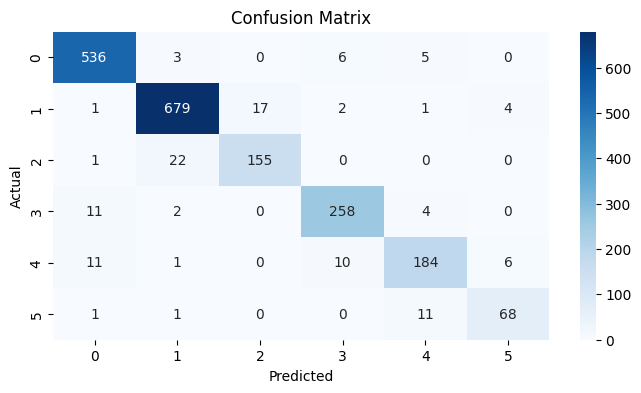

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))
cm = confusion_matrix(y_val, y_pred)
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
# Install protobuf (needed for model serialization)
! pip install protobuf

# Install sentencepiece (needed for many HuggingFace tokenizers)
! pip install sentencepiece

# Optional but recommended: install tokenizers and accelerate
! pip install tokenizers accelerate



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [33]:
! pip install protobuf sentencepiece


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# সরাসরি Hugging Face Hub থেকে মডেল লোড করো
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

def predict_emotion(sentence):
    inputs = tokenizer([sentence], return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()
    class_id = np.argmax(probs)

    # Hugging Face মডেলের config থেকে লেবেল নাম বের করো
    emotion = model.config.id2label[class_id]
    return emotion, probs

# Demo
sentence = "I am feeling very happy today!"
emotion, prob = predict_emotion(sentence)

print("Sentence:", sentence)
print("Predicted Emotion:", emotion)
print("Probabilities:", prob)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1525.31it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Sentence: I am feeling very happy today!
Predicted Emotion: LABEL_0
Probabilities: [[0.5143328  0.48566717]]


In [35]:
model.config.id2label = {0: "sad", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
model.config.label2id = {"sad": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}
model.save_pretrained("train_result/final")
tokenizer.save_pretrained("train_result/final")


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.59s/it]


('train_result/final/tokenizer_config.json',
 'train_result/final/tokenizer.json')

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
! pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 MB 187.3 kB/s eta 0:00:0000:0101:06
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 202.9 kB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 437.0 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 167.2 kB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 200.7 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 228.4 kB/s eta 0:00:00:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 162.7 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 135.7 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 134.9 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 121.2 kB/s eta 0:00:00a 0:00:01
  Using cached wheel-0.46.3-py3-none-any.whl (30 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419

In [38]:
# =========================
# 1. Import Libraries
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# =========================
# 2. Data Preparation
# =========================
x_train_text = df_train['text']
x_test_text = df_test['text']

y_train = df_train['label']
y_test = df_test['label']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

x_train_vec = vectorizer.fit_transform(x_train_text).toarray()
x_test_vec = vectorizer.transform(x_test_text).toarray()

# Tensor
x_train = torch.tensor(x_train_vec, dtype=torch.long)
x_test = torch.tensor(x_test_vec, dtype=torch.long)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [40]:
class CustomDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [41]:
dataset = CustomDataset(x_train, y_train)

In [42]:
len(dataset)

16000

In [43]:
dataset[22]

(tensor([0, 0, 0,  ..., 0, 0, 0]), tensor(1))

In [ ]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6):
        super(NeuralNet, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),   # dropout rate বাড়ানো হয়েছে

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),

            nn.Linear(64, 32), # hidden dimension কমানো হয়েছে (16 → 32)
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=6):
        super(LSTMClassifier, self).__init__()

        # Embedding layer: token IDs → dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # BatchNorm + Dropout after LSTM
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(0.4)

        # Hidden FC layer
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.relu1 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.4)

        # Another hidden FC layer
        self.fc2 = nn.Linear(64, 16)
        self.relu2 = nn.ReLU()
        self.batchnorm3 = nn.BatchNorm1d(16)
        self.dropout3 = nn.Dropout(0.4)

        # Output layer
        self.fc_out = nn.Linear(16, num_classes)

    def forward(self, x):
        # Step 1: Embedding
        embedded = self.embedding(x)   # [batch, seq_len, embed_dim]

        # Step 2: LSTM
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        h_n = h_n.squeeze(0)           # [batch, hidden_dim]

        # Step 3: BatchNorm + Dropout
        h_n = self.batchnorm1(h_n)
        h_n = self.dropout1(h_n)

        # Step 4: Hidden FC layers
        x = self.fc1(h_n)
        x = self.relu1(x)
        x = self.batchnorm2(x)
        x = self.dropout2(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.batchnorm3(x)
        x = self.dropout3(x)

        # Step 5: Output
        output = self.fc_out(x)
        return output


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer দিয়ে vocab বানানো
vectorizer = CountVectorizer()
vectorizer.fit(df_train["text"])

# Vocabulary size বের করা
vocab_size = len(vectorizer.vocabulary_)
num_classes = 6
print("Vocabulary Size:", vocab_size)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# model = NeuralNet()
model = LSTMModel(vocab_size=vocab_size, num_classes=num_classes)
model.to(device)

TypeError: LSTMModel.__init__() missing 1 required positional argument: 'vocab_size'

In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
for x, y in dataloader:
    print(x.shape, " " ,y)

torch.Size([32, 5000])   tensor([1, 1, 0, 1, 0, 3, 3, 0, 0, 0, 4, 3, 0, 1, 0, 3, 3, 4, 1, 0, 0, 2, 3, 1,
        3, 3, 1, 0, 0, 4, 0, 3])
torch.Size([32, 5000])   tensor([0, 0, 4, 4, 2, 4, 1, 0, 1, 1, 4, 3, 1, 1, 0, 4, 1, 0, 1, 0, 1, 1, 3, 1,
        0, 3, 0, 0, 1, 3, 2, 1])
torch.Size([32, 5000])   tensor([0, 1, 5, 3, 3, 0, 1, 1, 4, 0, 1, 0, 4, 4, 2, 5, 0, 4, 4, 1, 1, 2, 1, 0,
        1, 1, 2, 1, 4, 3, 0, 0])
torch.Size([32, 5000])   tensor([0, 2, 2, 3, 1, 0, 1, 3, 0, 1, 1, 3, 1, 2, 2, 0, 4, 0, 1, 0, 4, 5, 1, 1,
        4, 3, 4, 0, 1, 0, 1, 4])
torch.Size([32, 5000])   tensor([1, 1, 1, 0, 1, 0, 3, 1, 1, 1, 4, 1, 1, 4, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
        0, 1, 0, 3, 3, 1, 1, 0])
torch.Size([32, 5000])   tensor([0, 1, 3, 1, 2, 1, 1, 0, 5, 1, 4, 2, 2, 3, 1, 0, 0, 2, 4, 1, 4, 1, 2, 0,
        1, 3, 1, 0, 2, 3, 0, 0])
torch.Size([32, 5000])   tensor([2, 1, 0, 2, 1, 0, 1, 3, 0, 0, 4, 1, 0, 1, 3, 3, 1, 1, 3, 1, 1, 0, 4, 1,
        0, 0, 1, 1, 1, 4, 0, 4])
torch.Size([32, 5000])   tensor([4

In [ ]:
model = NeuralNet()
# model = LSTMNet()

In [ ]:
# =========================
# 4. Loss & Optimizer
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# 5. EarlyStopping Class
# =========================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_score = None
        self.counter = 0
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_weights = model.state_dict()

        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
        else:
            self.best_score = val_acc
            self.best_weights = model.state_dict()
            self.counter = 0

# =========================
# 6. Training Loop
# =========================
early_stopping = EarlyStopping(patience=5)

epochs = 100
batch_size = 16

for epoch in range(epochs):
    model.train()

    permutation = torch.randperm(x_train.shape[0])
    total_loss = 0

    for i in range(0, x_train.shape[0], batch_size):
        indices = permutation[i:i+batch_size]

        batch_x = x_train[indices].float()
        batch_y = y_train[indices]

        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ===== Validation =====
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_test.float())

        _, preds = torch.max(val_outputs, 1)
        val_acc = (preds == y_test).float().mean().item()

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

    # EarlyStopping
    early_stopping(val_acc, model)

    if early_stopping.early_stop:
        print("🔥 Early Stopping Triggered!")
        break

# =========================
# 7. Final Evaluation
# =========================
model.eval()
with torch.no_grad():
    outputs = model(x_test.float())
    _, preds = torch.max(outputs, 1)

accuracy = accuracy_score(y_test.numpy(), preds.numpy())
print("\nFinal Accuracy:", accuracy)


Epoch 01 | Loss: 1575.3538 | Val Acc: 0.3475
Epoch 02 | Loss: 1575.3752 | Val Acc: 0.3475
Epoch 03 | Loss: 1575.5111 | Val Acc: 0.3475
Epoch 04 | Loss: 1575.4087 | Val Acc: 0.3475
Epoch 05 | Loss: 1575.4828 | Val Acc: 0.3475
Epoch 06 | Loss: 1575.4431 | Val Acc: 0.3475
Epoch 07 | Loss: 1575.5048 | Val Acc: 0.3475
Epoch 08 | Loss: 1575.4186 | Val Acc: 0.3475
Epoch 09 | Loss: 1575.4150 | Val Acc: 0.3475
Epoch 10 | Loss: 1575.3733 | Val Acc: 0.3475

Final Accuracy: 0.3475


In [ ]:
label_map = {
    0: "sad",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def predict_emotion(sentence):
    model.eval()

    vec = vectorizer.transform([sentence]).toarray()
    vec = torch.tensor(vec, dtype=torch.float32)

    with torch.no_grad():
        output = model(vec)
        pred = torch.argmax(output, dim=1).item()

    return label_map[pred]

# Demo
print(predict_emotion("I will kill you by using knife"))

sad


In [ ]:
from sklearn.metrics import classification_report

# model evaluation mode
model.eval()

with torch.no_grad():
    outputs = model(x_test.float())
    _, preds = torch.max(outputs, 1)

# numpy এ convert
y_true = y_test.numpy()
y_pred = preds.numpy()

# report print
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       581
           1       0.35      1.00      0.52       695
           2       0.00      0.00      0.00       159
           3       0.00      0.00      0.00       275
           4       0.00      0.00      0.00       224
           5       0.00      0.00      0.00        66

    accuracy                           0.35      2000
   macro avg       0.06      0.17      0.09      2000
weighted avg       0.12      0.35      0.18      2000



/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
target_names = ["sad", "joy", "love", "anger", "fear", "surprise"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

         sad       0.00      0.00      0.00       581
         joy       0.35      1.00      0.52       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.35      2000
   macro avg       0.06      0.17      0.09      2000
weighted avg       0.12      0.35      0.18      2000



/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(df)

      Metric     Value
0   Accuracy  0.347500
1  Precision  0.120756
2     Recall  0.347500
3   F1-Score  0.179230


/home/ebratul/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import torch

# Train/test split
x_train_text = df_train['text']
x_test_text = df_test['text']
y_train = df_train['label']
y_test = df_test['label']

# Convert text → numeric features (Bag-of-Words)
vectorizer = CountVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(x_train_text).toarray()
X_test = vectorizer.transform(x_test_text).toarray()

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)


In [33]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Train/Test dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [34]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [51]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [36]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=float(lr), weight_decay=1e-5)
    early_stopping = EarlyStopping(patience=patience)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss /= len(test_loader)
        val_acc = val_correct / val_total

        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_losses, val_losses, train_accs, val_accs

In [37]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6):
        super(NeuralNet, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),   # dropout rate বাড়ানো হয়েছে

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),

            nn.Linear(64, 32), # hidden dimension কমানো হয়েছে (16 → 32)
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [38]:
import torch
import torch.nn as nn

class LSTMFeatures(nn.Module):
    def __init__(self, input_dim=5000, hidden_dim=64, num_classes=6):
        super(LSTMFeatures, self).__init__()
        # hidden_dim কমানো হয়েছে (128 → 64) যাতে মডেল কম complex হয়
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=0.5)

        # FC layer with stronger dropout
        self.fc = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.5),   # dropout rate বাড়ানো হয়েছে
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [batch, seq_len=1, input_dim]
        _, (h_n, _) = self.lstm(x)
        h_n = h_n.squeeze(0)
        return self.fc(h_n)


In [39]:
import torch
import torch.nn as nn

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6, hidden_dim=128, nhead=4, num_layers=2):
        super(TransformerClassifier, self).__init__()
        
        # Input projection
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        
        # Transformer encoder with dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, 
            nhead=nhead, 
            dropout=0.5,          # dropout rate বাড়ানো হয়েছে
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Regularization layers
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.5)
        
        # Output
        self.fc_out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Project input features
        x = self.fc_in(x).unsqueeze(1)  # [batch, seq_len=1, hidden_dim]
        
        # Transformer encoder
        x = self.transformer(x)
        
        # Pooling + regularization
        x = x.mean(dim=1)               # mean pooling
        x = self.layernorm(x)
        x = self.dropout(x)
        
        return self.fc_out(x)


In [40]:
class CNNClassifier(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6):
        super(CNNClassifier, self).__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool1d(4)   # বেশি pooling → dimension ছোট হবে
        self.dropout1 = nn.Dropout(0.5)

        # Conv block 2
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)
        self.dropout2 = nn.Dropout(0.5)

        # Global average pooling → huge flatten এড়ানো
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Fully connected
        self.fc1 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)              # [batch, 1, input_dim]
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        # Global average pooling → [batch, 64, 1]
        x = self.gap(x)
        x = x.squeeze(-1)               # [batch, 64]

        x = self.fc1(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)

        return self.fc_out(x)


In [42]:
print("start NN training....")
model_nn = NeuralNet(input_dim=X_train.shape[1], num_classes=6)
train_losses, val_losses, train_accs, val_accs = train_model(model_nn, train_loader, test_loader)


start NN training....
Epoch 1/50 | Train Loss: 1.6102 | Train Acc: 0.3754 | Val Loss: 1.1147 | Val Acc: 0.5960
Epoch 2/50 | Train Loss: 1.0932 | Train Acc: 0.6017 | Val Loss: 0.7985 | Val Acc: 0.6925
Epoch 3/50 | Train Loss: 0.8078 | Train Acc: 0.7127 | Val Loss: 0.5339 | Val Acc: 0.8275
Epoch 4/50 | Train Loss: 0.6157 | Train Acc: 0.7961 | Val Loss: 0.4243 | Val Acc: 0.8545
Epoch 5/50 | Train Loss: 0.4820 | Train Acc: 0.8488 | Val Loss: 0.3948 | Val Acc: 0.8720
Epoch 6/50 | Train Loss: 0.4218 | Train Acc: 0.8676 | Val Loss: 0.3833 | Val Acc: 0.8720
Epoch 7/50 | Train Loss: 0.3632 | Train Acc: 0.8884 | Val Loss: 0.3898 | Val Acc: 0.8685
Epoch 8/50 | Train Loss: 0.3250 | Train Acc: 0.9004 | Val Loss: 0.3813 | Val Acc: 0.8720
Epoch 9/50 | Train Loss: 0.2937 | Train Acc: 0.9139 | Val Loss: 0.3989 | Val Acc: 0.8695
Epoch 10/50 | Train Loss: 0.2815 | Train Acc: 0.9147 | Val Loss: 0.3914 | Val Acc: 0.8775
Epoch 11/50 | Train Loss: 0.2693 | Train Acc: 0.9202 | Val Loss: 0.4040 | Val Acc: 0.87

In [46]:
# LSTM
print("start LSTM traning....")


# Model initialize
model_lstm = LSTMFeatures(input_dim=X_train.shape[1], num_classes=6)


# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_lstm, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)

start LSTM traning....
Epoch 1/50 | Train Loss: 1.2908 | Train Acc: 0.5191 | Val Loss: 0.5919 | Val Acc: 0.8405
Epoch 2/50 | Train Loss: 0.4219 | Train Acc: 0.8668 | Val Loss: 0.3181 | Val Acc: 0.8915
Epoch 3/50 | Train Loss: 0.2410 | Train Acc: 0.9213 | Val Loss: 0.3097 | Val Acc: 0.8865
Epoch 4/50 | Train Loss: 0.1768 | Train Acc: 0.9416 | Val Loss: 0.3282 | Val Acc: 0.8835
Epoch 5/50 | Train Loss: 0.1431 | Train Acc: 0.9531 | Val Loss: 0.3371 | Val Acc: 0.8790
Epoch 6/50 | Train Loss: 0.1270 | Train Acc: 0.9586 | Val Loss: 0.3537 | Val Acc: 0.8805
Epoch 7/50 | Train Loss: 0.1151 | Train Acc: 0.9606 | Val Loss: 0.3857 | Val Acc: 0.8775
Epoch 8/50 | Train Loss: 0.1002 | Train Acc: 0.9667 | Val Loss: 0.3744 | Val Acc: 0.8860
Early stopping triggered!


In [50]:
# Transformer

print("start Transformer traning....")


# Transformer Model initialize
model_trans = TransformerClassifier(input_dim=X_train.shape[1], num_classes=6)

# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_trans, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)


start Transformer traning....


Epoch 1/50 | Train Loss: 0.8777 | Train Acc: 0.6941 | Val Loss: 0.5326 | Val Acc: 0.8355
Epoch 2/50 | Train Loss: 0.3493 | Train Acc: 0.8926 | Val Loss: 0.5622 | Val Acc: 0.8415
Epoch 3/50 | Train Loss: 0.2521 | Train Acc: 0.9224 | Val Loss: 0.6009 | Val Acc: 0.8455
Epoch 4/50 | Train Loss: 0.2063 | Train Acc: 0.9353 | Val Loss: 0.6323 | Val Acc: 0.8410
Epoch 5/50 | Train Loss: 0.1711 | Train Acc: 0.9472 | Val Loss: 0.6382 | Val Acc: 0.8565
Epoch 6/50 | Train Loss: 0.1473 | Train Acc: 0.9537 | Val Loss: 0.7713 | Val Acc: 0.8545
Early stopping triggered!


In [48]:

# CNN

# CNN Model initialize
model_cnn = CNNClassifier(input_dim=X_train.shape[1], num_classes=6)

# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_cnn, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)

Epoch 1/50 | Train Loss: 1.6620 | Train Acc: 0.3115 | Val Loss: 1.5804 | Val Acc: 0.3415
Epoch 2/50 | Train Loss: 1.6048 | Train Acc: 0.3329 | Val Loss: 1.5809 | Val Acc: 0.3475
Epoch 3/50 | Train Loss: 1.5910 | Train Acc: 0.3382 | Val Loss: 1.5735 | Val Acc: 0.3475
Epoch 4/50 | Train Loss: 1.5853 | Train Acc: 0.3367 | Val Loss: 1.5749 | Val Acc: 0.3460
Epoch 5/50 | Train Loss: 1.5803 | Train Acc: 0.3395 | Val Loss: 1.5665 | Val Acc: 0.3235
Epoch 6/50 | Train Loss: 1.5796 | Train Acc: 0.3391 | Val Loss: 1.5665 | Val Acc: 0.3420
Epoch 7/50 | Train Loss: 1.5782 | Train Acc: 0.3384 | Val Loss: 1.5648 | Val Acc: 0.3495
Epoch 8/50 | Train Loss: 1.5759 | Train Acc: 0.3390 | Val Loss: 1.5635 | Val Acc: 0.3475
Epoch 9/50 | Train Loss: 1.5764 | Train Acc: 0.3408 | Val Loss: 1.5628 | Val Acc: 0.3420
Epoch 10/50 | Train Loss: 1.5754 | Train Acc: 0.3397 | Val Loss: 1.5629 | Val Acc: 0.3445
Epoch 11/50 | Train Loss: 1.5753 | Train Acc: 0.3387 | Val Loss: 1.5624 | Val Acc: 0.3370
Epoch 12/50 | Train

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Precision, Recall, F1 (macro average for multi-class)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1


In [58]:
# ধরো তুমি CNN train করেছো
acc, prec, rec, f1 = evaluate_metrics(model_cnn, test_loader)


# # অথবা LSTM/Transformer/NN এর জন্যও একইভাবে
# acc, prec, rec, f1 = evaluate_metrics(model_lstm, test_loader)


Accuracy:  0.3490
Precision: 0.1138
Recall:    0.1717
F1-Score:  0.1190


/home/ebratul/Documents/code/mubarak/torch_gpu_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import matplotlib.pyplot as plt

def plot_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(12,5))

    # Loss curves
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Accuracy curves
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs, 'r-', label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.show()


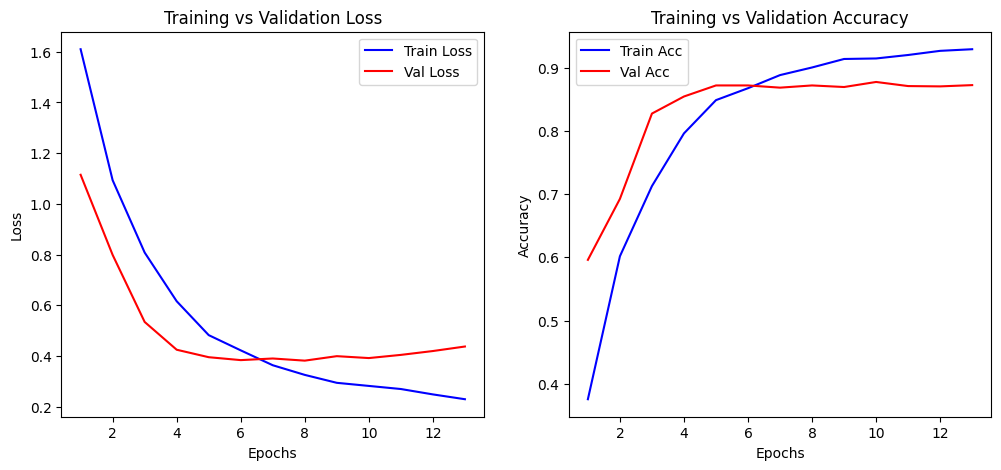

In [44]:
plot_curves(train_losses, val_losses, train_accs, val_accs)